# Naive Bayes Classification

Naive Bayes is a probabilistic machine learning algorithm based on Bayes' theorem with the assumption of conditional independence between features. Despite its simplicity, it often performs surprisingly well on real-world problems.

## 1. Bayes' Theorem

Bayes' theorem describes the probability of an event, based on prior knowledge of conditions that might be related to the event:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Where:
- $P(A|B)$ is the posterior probability (what we want to find)
- $P(B|A)$ is the likelihood
- $P(A)$ is the prior probability
- $P(B)$ is the marginal probability (evidence)

## 2. Naive Bayes for Classification

For classification, we want to find the class $C$ that maximizes:

$$P(C|X_1, X_2..., X_n) = \frac{P(X_1, X_2..., X_n|C) \cdot P(C)}{P(X_1, X_2..., X_n)}$$

The **naive assumption** assumes conditional independence of features given the class:

$$P(X_1, X_2..., X_n|C) = P(X_1|C) \cdot P(X_2|C) \cdot ... \cdot P(X_n|C)$$

This simplification makes the algorithm computationally efficient.

## 3. Implementation from Scratch

In [1]:
import numpy as np
from collections import defaultdict
import math

class NaiveBayesClassifier:
    """Naive Bayes classifier for continuous features using Gaussian distribution."""
    
    def __init__(self):
        self.class_priors = {}
        self.feature_stats = defaultdict(lambda: defaultdict(dict))  # {class: {feature: {mean, std}}}
        self.classes = None
    
    def fit(self, X, y):
        """Fit the classifier to training data.
        
        Args:
            X: Training features (n_samples, n_features)
            y: Training labels (n_samples,)
        """
        self.classes = np.unique(y)
        n_samples = X.shape[0]
        
        # Calculate class priors
        for c in self.classes:
            self.class_priors[c] = np.sum(y == c) / n_samples
        
        # Calculate feature statistics for each class
        for c in self.classes:
            X_c = X[y == c]
            for feature_idx in range(X.shape[1]):
                self.feature_stats[c][feature_idx]['mean'] = X_c[:, feature_idx].mean()
                self.feature_stats[c][feature_idx]['std'] = X_c[:, feature_idx].std()
    
    def _gaussian_pdf(self, x, mean, std):
        """Calculate Gaussian probability density function."""
        numerator = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
        denominator = std * np.sqrt(2 * np.pi)
        return numerator / denominator
    
    def predict(self, X):
        """Predict class for samples in X.
        
        Args:
            X: Features to predict (n_samples, n_features)
            
        Returns:
            Predicted class labels
        """
        predictions = []
        
        for sample in X:
            posteriors = {}
            
            for c in self.classes:
                # Start with class prior (log scale to avoid underflow)
                posteriors[c] = np.log(self.class_priors[c])
                
                # Multiply likelihood for each feature
                for feature_idx, x in enumerate(sample):
                    mean = self.feature_stats[c][feature_idx]['mean']
                    std = self.feature_stats[c][feature_idx]['std']
                    posteriors[c] += np.log(self._gaussian_pdf(x, mean, std))
            
            # Choose class with highest posterior
            predictions.append(max(posteriors, key=posteriors.get))
        
        return np.array(predictions)
    
    def score(self, X, y):
        """Calculate accuracy score."""
        predictions = self.predict(X)
        accuracy = np.sum(predictions == y) / len(y)
        return accuracy

print("Naive Bayes classifier implemented!")

Naive Bayes classifier implemented!


## 4. Test on Iris Dataset

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train our implementation
nb_classifier = NaiveBayesClassifier()
nb_classifier.fit(X_train, y_train)

# Make predictions
y_pred = nb_classifier.predict(X_test)

# Evaluate
accuracy = nb_classifier.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.9778

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



## 5. Confusion Matrix Visualization

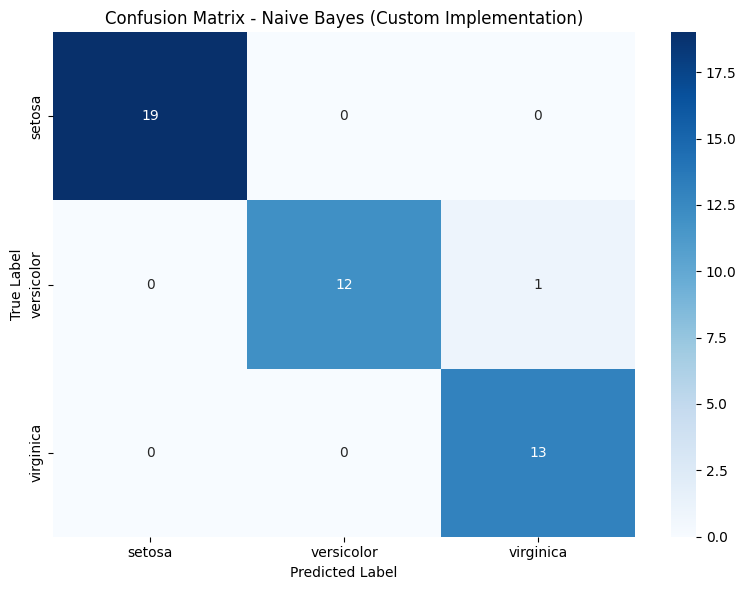

In [3]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Naive Bayes (Custom Implementation)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 6. Compare with scikit-learn

In [4]:
from sklearn.naive_bayes import GaussianNB

# Train scikit-learn implementation
sklearn_nb = GaussianNB()
sklearn_nb.fit(X_train, y_train)

# Predictions
y_pred_sklearn = sklearn_nb.predict(X_test)

# Compare accuracies
custom_accuracy = accuracy_score(y_test, y_pred)
sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)

print(f"Custom Implementation Accuracy: {custom_accuracy:.4f}")
print(f"Scikit-learn Implementation Accuracy: {sklearn_accuracy:.4f}")
print(f"\nDifference: {abs(custom_accuracy - sklearn_accuracy):.4f}")

Custom Implementation Accuracy: 0.9778
Scikit-learn Implementation Accuracy: 0.9778

Difference: 0.0000


## 7. Text Classification Example (Spam Detection)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Sample spam/ham messages
messages = [
    "Free money!! Claim now",
    "Hi, how are you?",
    "WINNER! You have won a prize",
    "Meeting at 3pm today",
    "Click here for amazing deals",
    "Let's catch up this weekend",
    "Congratulations! You have won",
    "See you tomorrow",
]

# Labels: 1 for spam, 0 for ham
labels = [1, 0, 1, 0, 1, 0, 1, 0]

# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(lowercase=True, stop_words='english')
X_tfidf = vectorizer.fit_transform(messages)

# Train classifier
spam_classifier = MultinomialNB()
spam_classifier.fit(X_tfidf, labels)

# Test on new messages
test_messages = [
    "Free gift card claim now!",
    "What time is the meeting?",
]

X_test_tfidf = vectorizer.transform(test_messages)
predictions = spam_classifier.predict(X_test_tfidf)
probabilities = spam_classifier.predict_proba(X_test_tfidf)

for message, pred, prob in zip(test_messages, predictions, probabilities):
    label = "SPAM" if pred == 1 else "HAM"
    confidence = prob[pred] * 100
    print(f"Message: {message}")
    print(f"Prediction: {label} (Confidence: {confidence:.2f}%)")
    print()

Message: Free gift card claim now!
Prediction: SPAM (Confidence: 64.05%)

Message: What time is the meeting?
Prediction: HAM (Confidence: 62.32%)



## 8. Advantages and Disadvantages

### Advantages:
- **Fast and efficient**: Simple to implement and train
- **Works well with small datasets**: Doesn't require large amounts of data
- **Good for text classification**: Often used for sentiment analysis and spam detection
- **Interpretable**: Easy to understand and explain
- **Handles multi-class problems**: Naturally extends to multiple classes

### Disadvantages:
- **Independence assumption**: Assumes features are independent, which is rarely true
- **Zero frequency problem**: If a feature doesn't appear in training data for a class, probability becomes zero
- **Continuous features**: Assumes Gaussian distribution for continuous features
- **Imbalanced data**: Can be biased toward majority class
- **Less accurate than complex models**: Often underperforms compared to more sophisticated algorithms

## 9. Types of Naive Bayes

| Type | Use Case |
|------|----------|
| **Gaussian NB** | Continuous features, assumes Gaussian distribution |
| **Multinomial NB** | Count data, text classification (word frequencies) |
| **Bernoulli NB** | Binary features, text with presence/absence of words |
| **Categorical NB** | Categorical features |
| **Complement NB** | Imbalanced datasets, better for text |

In [6]:
# Example: Using different Naive Bayes variants
from sklearn.naive_bayes import BernoulliNB, CategoricalNB

print("Different Naive Bayes variants available in scikit-learn:")
print("1. GaussianNB - For continuous features")
print("2. MultinomialNB - For count/frequency data")
print("3. BernoulliNB - For binary features")
print("4. CategoricalNB - For categorical features")
print("5. ComplementNB - Better for imbalanced datasets")

Different Naive Bayes variants available in scikit-learn:
1. GaussianNB - For continuous features
2. MultinomialNB - For count/frequency data
3. BernoulliNB - For binary features
4. CategoricalNB - For categorical features
5. ComplementNB - Better for imbalanced datasets


## 10. Summary

Naive Bayes is a powerful and efficient probabilistic classifier that works well despite its simplifying assumptions. It's particularly useful for:
- Text classification and NLP tasks
- Spam detection
- Sentiment analysis
- Quick baseline models
- Datasets with limited examples

The algorithm's simplicity makes it an excellent starting point for classification problems, and it often serves as a strong baseline to compare against more complex models.